In [1]:
import scanpy as sc
import torch
from matplotlib import pyplot as plt
import numpy as np

from src.models.destvi import DestVI
from src.models.condscvi import CondSCVI


sc_adata = sc.read_h5ad("../data/simulation_Mouse_Kidney_MERFISH/MERFISH_kidney_object.h5ad")
st_adata = sc.read_h5ad("../data/simulation_Mouse_Kidney_MERFISH/MK_simulated_ST.h5ad")
print(sc_adata)
print(st_adata)

/home/pxy/miniconda3/envs/destvi/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 126547 × 307
    obs: 'fov', 'volume', 'center_x', 'center_y', 'min_x', 'min_y', 'max_x', 'max_y', 'barcodeCount', 'average_DAPI_score', 'area', 'n_counts', 'leiden', 'free_annotation'
    uns: 'free_annotation_colors', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'
AnnData object with n_obs × n_vars = 1520 × 307
    obs: 'spot_id', 'n_cells'
    uns: 'cell_types'
    obsm: 'spatial', 'true_proportion'


In [3]:
CondSCVI.setup_anndata(sc_adata, layer="counts", labels_key="free_annotation")

In [ ]:
# 训练CondSCVI
sc_model = CondSCVI(sc_adata, weight_obs=False)
sc_model.view_anndata_setup()

Anndata setup with scvi-tools version 1.3.3.

Setup via `CondSCVI.setup_anndata` with arguments:

{'labels_key': 'free_annotation', 'layer': 'counts', 'batch_key': None}

     Summary Statistics      
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃ Summary Stat Key ┃ Value  ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│     n_batch      │   1    │
│     n_cells      │ 126547 │
│     n_labels     │   8    │
│      n_vars      │  307   │
└──────────────────┴────────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │  adata.layers['counts']   │
│    batch     │ adata.obs['_scvi_batch']  │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                                         labels State Registry                                          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃       Source Location        ┃                   Categories                    ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['free_annotation'] │                endothelial cell                 │          0          │
│                              │       epithelial cell of proximal tubule        │          1          │
│                              │     kidney collecting duct epithelial cell      │          2          │
│                              │ kidney distal convoluted tubule epithelial cell │          3          │
│                              │      kidney loop of Henle epithelial cell       │          4          │
│                              │                    podocyte                     │          5          │
│                              │                   immune cell                   │          6          │
│                              │                    pericyte                     │          7          │
└──────────────────────────────┴─────────────────────────────────────────────────┴─────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_batch'] │     0      │          0          │
└──────────────────────────┴────────────┴─────────────────────┘

In [6]:
# callback = PrintLossCallback(print_every_n_epochs=10)
# sc_model.train(callbacks=[callback])
sc_model.train()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/pxy/miniconda3/envs/destvi/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Epoch 300/300: 100%|██████████| 300/300 [1:11:18<00:00, 14.19s/it, v_num=1, train_loss_step=143, train_loss_epoch=149]

`Trainer.fit` stopped: `max_epochs=300` reached.


Epoch 300/300: 100%|██████████| 300/300 [1:11:18<00:00, 14.26s/it, v_num=1, train_loss_step=143, train_loss_epoch=149]


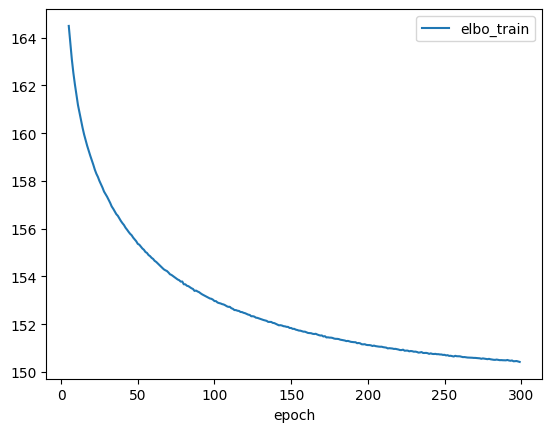

In [7]:
sc_model.history["elbo_train"].iloc[5:].plot()
plt.show()

In [8]:
DestVI.setup_anndata(st_adata)

/home/pxy/home/pxy/scvi-tools-DestVI/src/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [9]:
st_model = DestVI.from_rna_model(st_adata, sc_model, amortization="both", dirichlet_alpha=0.2, dirichlet_mmd_reg=5, l1_reg=0.0)
st_model.view_anndata_setup()

Anndata setup with scvi-tools version 1.3.3.

Setup via `DestVI.setup_anndata` with arguments:

{'layer': None}

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│     n_cells      │ 1520  │
│      n_vars      │  307  │
└──────────────────┴───────┘

             Data Registry              
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃  scvi-tools Location  ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │        adata.X        │
│    ind_x     │ adata.obs['_indices'] │
└──────────────┴───────────────────────┘

In [10]:
st_model.train(max_epochs=1500)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/pxy/miniconda3/envs/destvi/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Epoch 1500/1500: 100%|██████████| 1500/1500 [06:08<00:00,  4.11it/s, v_num=1, train_loss_step=2.22e+6, train_loss_epoch=2.2e+6] 

`Trainer.fit` stopped: `max_epochs=1500` reached.


Epoch 1500/1500: 100%|██████████| 1500/1500 [06:08<00:00,  4.07it/s, v_num=1, train_loss_step=2.22e+6, train_loss_epoch=2.2e+6]


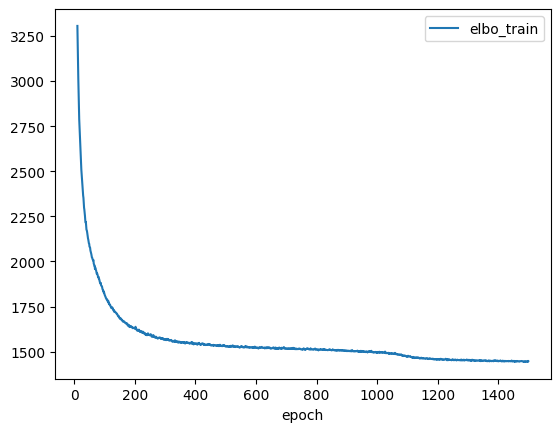

In [11]:
st_model.history["elbo_train"].iloc[10:].plot()
plt.show()

提取计算的细胞类型比例

In [12]:
st_adata.obsm["proportions"] = st_model.get_proportions()

In [13]:
proportions_df = st_adata.obsm["proportions"]
proportions_df.to_csv("destvi_predicted_proportions.csv", index=True)

In [14]:
st_adata.obsm["proportions"].head(5)

,endothelial cell,epithelial cell of proximal tubule,kidney collecting duct epithelial cell,kidney distal convoluted tubule epithelial cell,kidney loop of Henle epithelial cell,podocyte,immune cell,pericyte
0,0.013171,0.984194,0.000108,0.000885,0.000028,0.000168,0.001446,6.641582e-09
1,0.058762,0.860984,0.002269,0.004365,0.000043,0.030973,0.042602,1.303661e-06
2,0.145282,0.782196,0.007300,0.004491,0.000276,0.053713,0.006715,2.682106e-05
3,0.258029,0.490192,0.034568,0.054938,0.006256,0.127001,0.024902,4.114225e-03
4,0.253351,0.527553,0.003821,0.003102,0.000052,0.137358,0.074741,2.145241e-05


可视化

In [15]:
ct_list = ["endothelial cell", "immune cell", "pericyte"]
for ct in ct_list:
    data = st_adata.obsm["proportions"][ct].values
    st_adata.obs[ct] = np.clip(data, 0, np.quantile(data, 0.99))

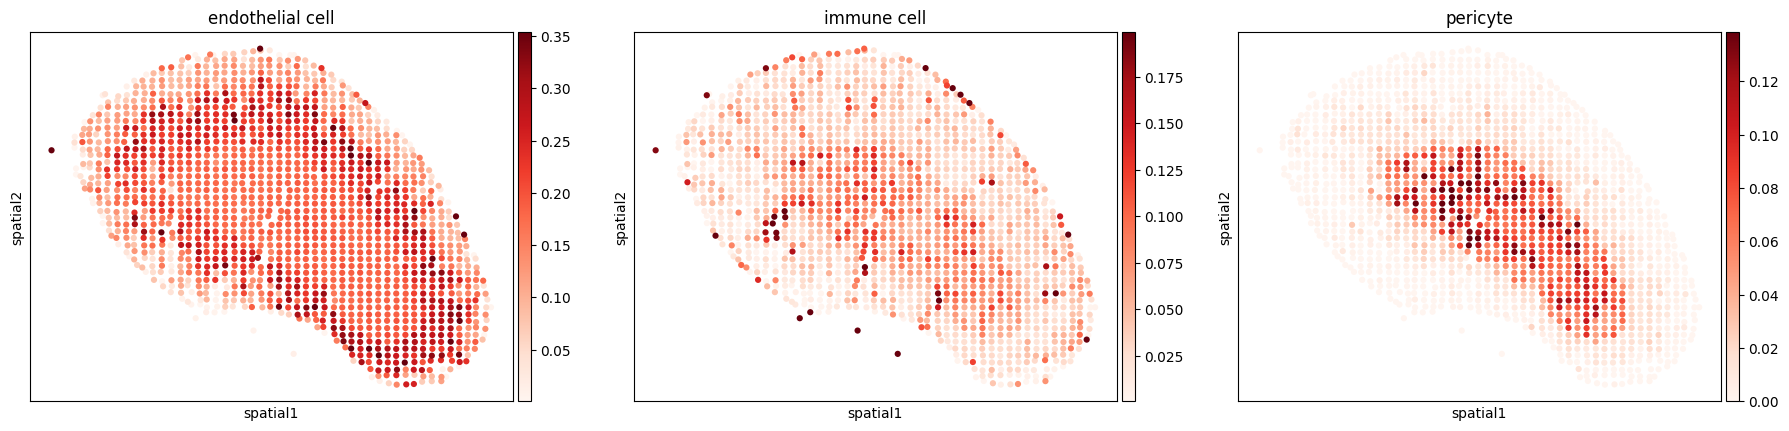

In [16]:
sc.pl.embedding(st_adata, basis="spatial", color=ct_list, cmap="Reds", s=80)